In [105]:
# https://judge.nitro-ai.org/competitions/slovenska-olympiada/slovak-aoi-2026/3/view

import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from tqdm.auto import tqdm 
import torch 
from torch import nn 
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

In [106]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

In [107]:
# load variational autoencoder
encoder = torch.load('mnist_cvae8_encoder.pth', weights_only=False, map_location=device)
decoder = torch.load('mnist_cvae8_decoder.pth', weights_only=False, map_location=device)
encoder.eval()
decoder.eval()

# binarize
def binarize(x):
    return (x > 0.5).float()

# run autocoder
def autoencoder(x, latent_dim=8):
    return decoder(encoder(x)[:,:latent_dim])

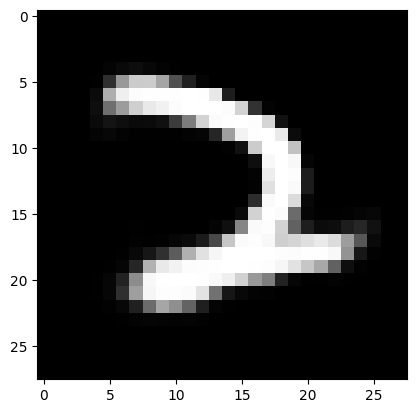

In [108]:
# Load image
directory = "train_data"
i=99
transform = transforms.ToTensor()
img = transform(Image.open(f"{directory}/{i:04d}.png"))

# Process image
batch = img.unsqueeze(0).to(device)
with torch.no_grad():
    result = autoencoder(batch)

# Display result
plt.imshow((result.squeeze(0).squeeze(0).cpu().numpy()*255).astype(np.uint8),cmap='gray')
plt.show()

In [109]:
num_binary = 0

for i in tqdm(range(10000)):
    img = np.array(Image.open(f"{directory}/{i:04d}.png"))
    num_binary += int(sorted(np.unique(img).tolist()) == [0, 255])

num_binary

  0%|          | 0/10000 [00:00<?, ?it/s]

10000

In [110]:
def get_errors(total=10000, batch_size=32):
    errors = np.zeros(total)
    for i in tqdm(range(0, total, batch_size)):
        imgs = torch.stack([transform(Image.open(f"{directory}/{it:04d}.png")) for it in range(i, min(total, i+batch_size))]).to(device)
        with torch.no_grad():
            result = autoencoder(imgs)

        errors[i:i+batch_size] = ((imgs - result) ** 2).view(imgs.shape[0], -1).mean(dim=1).cpu().numpy()
    return errors

In [111]:
errors = get_errors()
errors[:10]

  0%|          | 0/313 [00:00<?, ?it/s]

array([0.1310623 , 0.03653736, 0.04742279, 0.17895313, 0.02624796,
       0.10266785, 0.02741642, 0.02210259, 0.1031804 , 0.10978094])

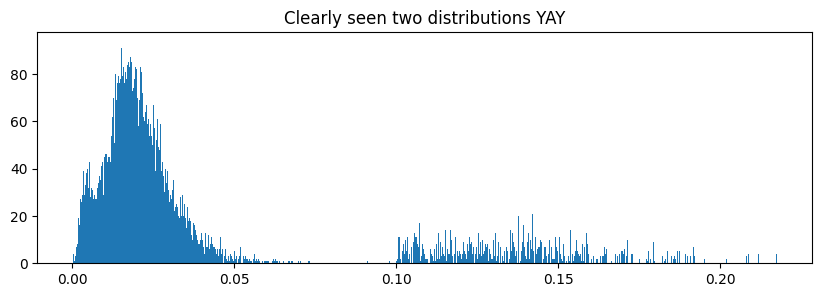

In [112]:
plt.figure(figsize=(10, 3))

plt.title('Clearly seen two distributions YAY')
plt.hist(errors, bins=1000)
plt.show()

In [113]:
errors[99], 'it was a digit in start'

(np.float64(0.020696688443422318), 'it was a digit in start')

In [114]:
print(letters)

CWAYCRRREPRNCKHDHEDNNFSHXBFUMRWWLXCWRDMSPVYVXQRQSYSBFVGUHMSMFRHEDMARQPWFFRSKEWMVVHQFYFQHCFUWFRWWCWVXFARRHBCAFSHSHXSRVBRNPNRVWWUHRRFDWVRUFDSRWAFNNDXFAYRUHPFEMPCCYFRDFRNUMHFHSWCRPVFQWWMRUWQXNCAHDRFMURDCSRVHVRNSDCFVURCRHXRUHCRHCCWNUWNSDDAUVCWDQRBCUCCWRWCFERFDRRNMVWRCRRWRHVFEFMVUYHFRWHHSRRXUXHMXCFUNRSCUHEFSWRFUKMFNDRDXCEWMWCRCHNREXKSQFAWHSUNFQYRUHSQHPBMRXEHWMUEVXHVKFHRMUWSVDUHWMYURVVREDCRNFHNNKRYRDDQNSPHACDRRUQFRVFWRNXMRVCYRXRFWFXHMAFQRXRRRYHUVRMYRRXXERHXRFMNDXWCXWVRQMMXQUFWADHCHSUDMURCFNDREYFMYDRFXYWQHRVSASWCHFMCXNVRRXCAMHUNXHFRVPRYXWBAUNCHSMSDUYCNFSNHFSMUHBBBNRXWWRYFHDSQRBNQNNSYFHVHWPSWUBHWYMAYXHHHRYDDMWRHAAKUFAUSSSSWWNQRNXNHUKBWRUFWRRYAQFGMVRFSYFAMWFDHMFHCUXWNRQBPCFYHCVRVWQNSWFUWDVEHUNUAWEWMDFXXWADWFXVFUWHCUCMSRNAXQCUFCVSHWDNUWCBUDCRCCNFBNMFWDDWDFRCVFMKWMCWRWHFQFBBNDHNCWXBCHHWVFHHDMSVDFFFNBRWMFCWFRWSXURYWDCHFRHQCNXVCQXWSWNMHRUXYUDCRNHHCHBYWXNAFRDQUDVRVQRXRFDQHCNHHAUHURWANWMAMQECHMUXNWVQSRRRCFFRWQXXMERXFWHMREMHQNYXUBWRANHRHPSHFAWWNHRUKUUAPFVQFDRCHMUHUDURMQWAMNDDQVVSMXRVRRFHDFUDNHRQHNFNHC

In [115]:
letters = [chr(i) for i in range(ord('A'), ord('Z')+1)]
examples = {l: [] for l in letters}
# just look at data
examples['A'] = [351, 5]
examples['B'] = [276, 101]
examples['C'] = [0, 9, 140]
examples['D'] = [327, 168, 56, 77]
examples['E'] = [322, 32, 62]
examples['F'] = [383, 314, 279, 91, 106]
examples['G'] = [285, ]
examples['H'] = [319, 291, 55, 61, 96]
examples['I'] = []
examples['J'] = []
examples['K'] = [54]
examples['L'] = [136]
examples['M'] = [339, 310, 313, 176, 115]
examples['N'] = [44, 79, 89]
# examples['O'] = [] there aren't such in there
examples['P'] = [366, 38, 190]
examples['Q'] = [360, 237, 232]
examples['R'] = [359, 316, 235, 157, 123, 14, 18, 31, 39]
examples['S'] = [249, 182, 92]
examples['T'] = []
examples['U'] = [288, 110]
examples['V'] = [281, 207, 224]
examples['W'] = [378, 3, 124, 126, 148]
examples['X'] = [231, 97, 138]
examples['Y'] = [253, 8, 217]
examples['Z'] = [329,]

In [116]:
def assign_letter(error):
    best, diff = 'A', 1.0
    for k, v in examples.items():
        for i in v:
            if abs(errors[i] - error) < diff: 
                diff = abs(errors[i] - error)
                best = k 
    return best

In [117]:
percentage = round(100*(num_binary / 10000), 2)
reconstruction_error = round(max(errors).item(), 5)
thresh = 0.075
indices = np.where(errors > thresh)[0]
count = len(indices)
# np.random.seed(42)
# letters = ''.join(np.random.choice([chr(i) for i in range(ord('A'), ord('Z')+1)], size=count, replace=True))
letters = ''.join([assign_letter(errors[i]) for i in indices])

# zoznam riadkov (subtask, referencia, odpoved)
rows = []

# Subtask 1
rows.append([1, 0, round(percentage,2)])

# Subtask 2
rows.append([2, 0, round(reconstruction_error,5)])

# Subtask 3
categories = [0]*10000
for index in indices:
    categories[index] = 1
for i, category in enumerate(categories):
    rows.append([3, i, category])

# Subtask 4
rows.append([4, 0, count])

# Subtask 5
characters = [' ']*10000
for index, letter in zip(indices, letters):
    characters[index] = letter
for i, character in enumerate(characters):
    rows.append([5, i, character])

# save to CSV (no header)
df = pd.DataFrame(rows, columns=["subtaskID", "datapointID", "answer"])
df.to_csv("submission.csv", index=False, header=True)
